# Utilizing Deep Learning for Drug lead optimization

In [ ]:
!pip install tensorflow==2.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 497.6/497.6 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.5/462.5 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 44.6 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: tensorboard-data-server
    Found existing installation: tensorboard-data-server 0.7.2
    Uninstalling tensorboard-data-server-0.7.2:
      Successfully uninstalled tensorboard-data-server-0.7.2
  Attempting uninstall: google-auth-oauthlib
    Found existing installation: g

In [ ]:

#@title  Importing Required Libraries
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib as mpl

import matplotlib.pyplot as plt
mpl.rcParams['figure.dpi'] = 300
%matplotlib inline

from tensorflow import keras
import numpy as np
from sklearn.metrics import f1_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Input,GRU,UpSampling1D, Conv1D, RepeatVector, MaxPooling1D, Activation,BatchNormalization, LSTM,Embedding, Dense, TimeDistributed, Bidirectional,concatenate, Dropout, LSTM
from tensorflow.keras.metrics import categorical_accuracy
from tensorflow.keras.layers import Convolution1D, SeparableConv1D, ConvLSTM1D, Lambda, GaussianNoise
#from keras.layers import  Dropout
from tensorflow.keras import backend  as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.preprocessing import text, sequence
from tensorflow.keras.preprocessing.text import Tokenizer
#from tensorflow.python.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Flatten, Reshape
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import add
from tensorflow.keras import metrics

import pickle
import random

import tensorflow._api.v2.compat.v1 as tf

tf.disable_v2_behavior()
!git clone https://github.com/rajkumar1501/drug_analog_data.git
!pip install rdkit-pypi
def load_dataset(data_set):
    # creating cleaned input, output pairs

    # Vectorize the input and target languages



    # English sentences

    with open('/content/drug_analog_data/smiles_indexs.pkl','rb') as f:
        #DrugIndex = [drugIndex.ch2idx,inp_lang.indx2ch]
        DrugIndex = pickle.load(f)
    target_tensor = [[DrugIndex[0][s] for s in list(mol)] for  mol in data_set]
    # Spanish sentences
    input_tensor = [[DrugIndex[0][s] for s in list(mol)] for mol in data_set]

    #input_pred = [[targ_lang.ch2idx[s] for s in list(mol)] for  mol in data_set]

    # Calculate max_length of input and output tensor
    # Here, we'll set those to the longest sentence in the dataset
    max_length_inp = max([len(i) for i in data_set])
    max_length_tar = max([len(i) for i in data_set])

    # Padding the input and output tensor to the maximum length
    input_tensor = tf.keras.preprocessing.sequence.pad_sequences(input_tensor,
                                                                 maxlen=100,
                                                                 padding='post',truncating='post')

       #input_pred = tf.keras.preprocessing.sequence.pad_sequences(input_pred,
                                                                 # maxlen=max_length_inp,
                                                                 # padding='post',truncating='post')
    return input_tensor, DrugIndex

#@title
maxlen = 100

def model(maxlen):
    input_1 = Input(shape=(maxlen,))
    layer_1 = Embedding(input_dim=45, output_dim=32, input_length=maxlen,name='Embedding')(input_1)

    layer_2 = LSTM(units=64, name = 'encoder_lstm',return_sequences=True)(layer_1)

    layer_3 = Dense(4, activation = 'relu',name='dense_1')(layer_2)
    #layer_3 = BatchNormalization(center=True,scale=True,name= 'batch')(layer_3)
    flatten = Flatten()(layer_3)
    layer_3 = Dense(100, activation = 'relu',name='dense_2')(flatten)
    layer_3 = BatchNormalization(center=True,scale=True,name= 'batch_b')(layer_3)





    encoder = Model(input_1, layer_3 )

    return encoder




vae_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
encoder = model(maxlen)




cc = keras.losses.CategoricalCrossentropy()

encoder.compile(loss= cc , optimizer=vae_optimizer, metrics=['categorical_accuracy'])
#model_2.load_weights('model_6_chemble_dense1_2.h5',by_name=True)
encoder.load_weights('/content/drug_analog_data/model_6_batch8192.h5',by_name=True)



#@title
maxlen = 100

def model(maxlen):
    input_1 = Input(shape=(maxlen,))
    layer_3 = Dense(200, activation = 'relu',name='dense_3')(input_1)

    layer_3 = Reshape((100, 2))(layer_3)


    layer_5 = TimeDistributed(Dense(64, activation="relu",name='decoder_2_0'),name = 'TD_3_0')(layer_3)
    layer_6 = LSTM(units=256,return_sequences=True,name='decoder_4_0')(layer_5)

    output = TimeDistributed(Dense(45, activation="softmax",name='final_0'),name='TD_4_0')(layer_6)
    model_2 = Model(input_1, output)

    return model_2


vae_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
decoder = model(maxlen)




cc = keras.losses.CategoricalCrossentropy()

decoder.compile(loss= cc , optimizer=vae_optimizer, metrics=['categorical_accuracy'])
#drug_gen.load_weights('model_6_chemble_dense1_2.h5',by_name=True)
decoder.load_weights('/content/drug_analog_data/model_6_batch8192.h5',by_name=True)


#@title
with open('/content/drug_analog_data/smiles_indexs.pkl','rb') as f:
    #DrugIndex = [drugIndex.ch2idx,inp_lang.indx2ch]
    DrugIndex = pickle.load(f)

#DrugIndex

#@title
def onehot_to_seq(oh_seq, index, maxlen):
    s = ''
    p_value=[]
    oh_seq = oh_seq.reshape(maxlen,45)
    for i in range(maxlen):
        temp = np.argmax(oh_seq[i])
        if temp != 0:
            s += index[temp]
            p_value.append(oh_seq[i][temp])
        else:
            break
    return s, p_value

def results(y_, maxlen):

        #revsere_decoder_index = {2:'d',1:'n'}
        S,p_values= onehot_to_seq(y_, DrugIndex[1], 100)
        p_values = ','.join([str(i.round(3)) for i in p_values])
        return S,str(p_values)




Instructions for updating:
non-resource variables are not supported in the long term


fatal: destination path 'drug_analog_data' already exists and is not an empty directory.


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Colocations handled automatically by placer.


Enter a chemical SMILES(length < 100): COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1
Length of the SMILES is 45. The model may not perfom well on SMILES length more than 80.


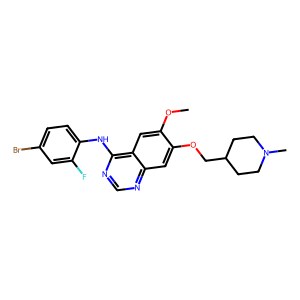

In [ ]:
#@title  Enter SMILES
d = input('Enter a chemical SMILES(length < 100): ').strip()
from rdkit.Chem import Draw
from rdkit import Chem
mol = Chem.MolFromSmiles(d)

print("Length of the SMILES is " +str(len(d))+". The model may not perfom well on SMILES length more than 80.")
Draw.MolToImage(mol)

/usr/local/lib/python3.10/dist-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
[10:17:28] SMILES Parse Error: extra close parentheses while parsing: COc1cc2c(nc3ccc(Br)cc3F)ncnc2cc1)CCNCCNCC1CC1
[10:17:28] SMILES Parse Error: Failed parsing SMILES 'COc1cc2c(nc3ccc(Br)cc3F)ncnc2cc1)CCNCCNCC1CC1' for input: 'COc1cc2c(nc3ccc(Br)cc3F)ncnc2cc1)CCNCCNCC1CC1'
[10:17:28] SMILES Parse Error: ring closure 1 duplicates bond between atom 23 and atom 26 for input: 'COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1(C)(C)C12'
[10:17:28] SMILES Parse Error: extra close parentheses while parsing: COc1cc2c(nc3ccc(Br)cc3F)nccc3cc1)OC1CC)(C)C1C
[10:17:28] SMILES Parse Error: Failed parsing SMILES 'COc1cc2c(nc3ccc(Br)cc3F)nccc3cc1)OC1CC)(C)C1C' for input: 'COc1cc2c(nc3ccc(Br)cc3F)nccc3cc1)OC1CC)(C)C1C'
[10:17:28] SMILES Parse Error: 

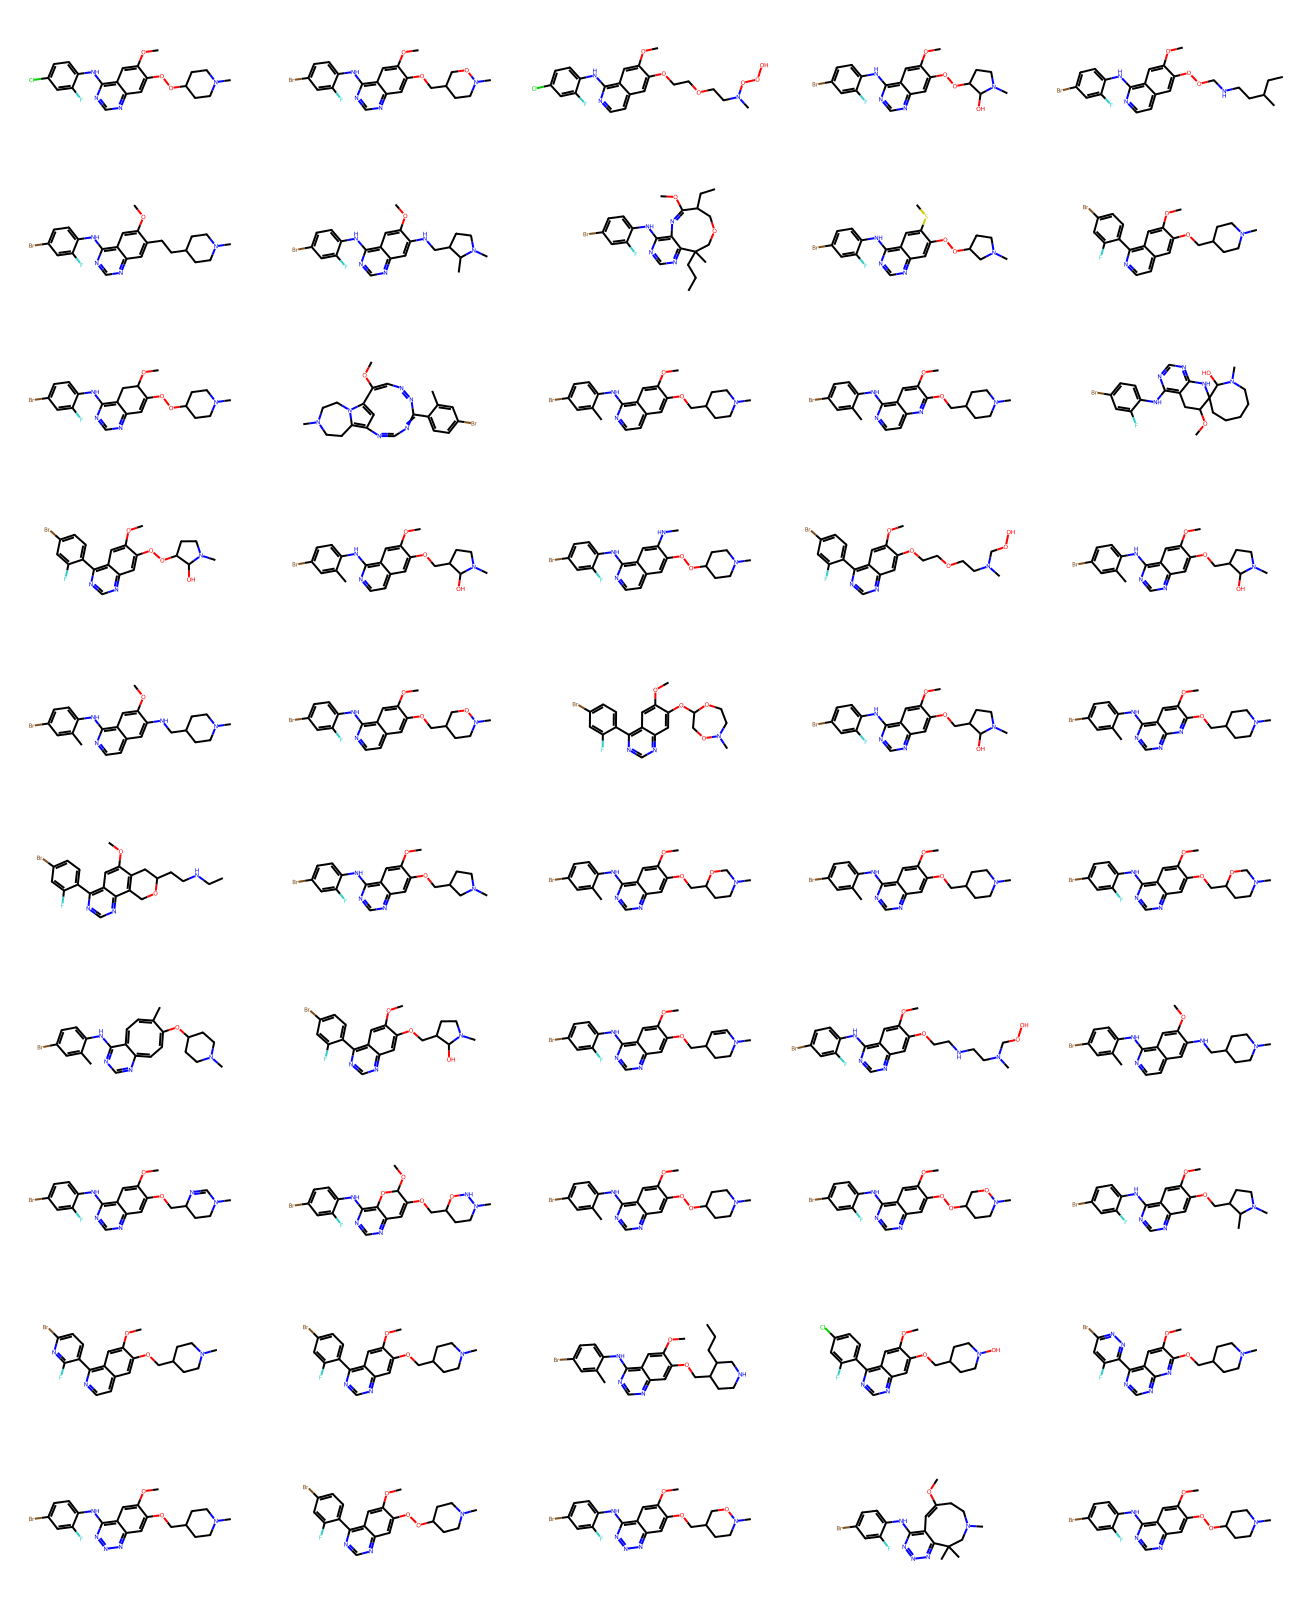

In [ ]:
#@title Predict Analogs
d_tensor,DrugIndex = load_dataset([d])
d_latent = encoder.predict(d_tensor)
#@title
from rdkit.Chem.Draw import MolsToGridImage
from rdkit import Chem
from rdkit.Chem import Draw,MolToSmiles
from rdkit.Chem.Draw import IPythonConsole
from rdkit import rdBase
##with open('gamma.pkl','rb') as f:
    #gamma = pickle.load(f)
def generator(num):
    mol = []
    for i in range(num):
        mu1 = 0 # mean and standard deviation
        seq_2 = np.random.normal(random.choice([-0.05,0.05]), random.choice([1,2]), 100)
        seq_2 = seq_2 + d_latent

        seq_2 = seq_2.reshape(1,100)
        y_train_pred = decoder.predict(seq_2)

        predicted_sec,pvalue = results(y_train_pred, maxlen)
        #predicted_sec
        mol.append(predicted_sec)
        #break
    return mol,pvalue


molecules,pvalue = generator(3000)

correct = []
correct_mol = []
molecules = set(molecules)
molecules = list(molecules)
#molecules = [i for i in molecules if len(i)<40]
for smi in molecules:
    try:
        mol = Chem.MolFromSmiles(smi)

        if mol is not None:
            correct_mol.append(smi)
            correct.append(mol)
    except:
        continue

MolsToGridImage(
    [m for m in correct  if m is not None], molsPerRow=5, subImgSize=(260, 160)
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#@title List of Analogs SMILES
print(correct_mol)

['COc1cc2c(Nc3ccc(Cl)cc3F)ncnc2cc1OOC1CCN(C)CC1', 'COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)OC1', 'COc1cc2c(Nc3ccc(Cl)cc3F)nccc2cc1OCCOCCN(C)OOO', 'COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OOC1CCN(C)C1O', 'COc1cc2c(Nc3ccc(Br)cc3F)nccc2cc1OOCNCCC(C)CC', 'COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1CCC1CCN(C)CC1', 'COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1NCC1CCN(C)C1C', 'COc1nc2c(Nc3ccc(Br)cc3F)ncnc2c(COCC1CC)(C)CCC', 'CSc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OOC1CCN(C)C1', 'COc1cc2c(-c3ccc(Br)cc3F)nccc2cc1OCC1CCN(C)CC1', 'COC1Cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OOC1CCN(C)CC1', 'COc1cnnc(-c3ccc(Br)cc3C)ncnc2cc1N1c2CCN(C)CC1', 'COc1cc2c(Nc3ccc(Br)cc3C)nccc2cc1OCC1CCN(C)CC1', 'COc1cc2c(Nc3ccc(Br)cc3C)nccc2nc1OCC1CCN(C)CC1', 'COC1Cc2c(Nc3ccc(Br)cc3F)ncnc2NC11CCCCCN(C)C1O', 'COc1cc2c(-c3ccc(Br)cc3F)ncnc2cc1OOC1CCN(C)C1O', 'COc1cc2c(Nc3ccc(Br)cc3C)nccc2cc1OCC1CCN(C)C1O', 'CNc1cc2c(Nc3ccc(Br)cc3F)nccc2cc1OOC1CCN(C)CC1', 'COc1cc2c(-c3ccc(Br)cc3F)ncnc2cc1OCCOCCN(C)COO', 'COc1cc2c(Nc3ccc(Br)cc3C)ncnc2cc1OCC1CCN(C)C1O', 'COc1cc2c(Nc3ccc(Br)c

In [ ]:
#@title Total Number of Analogs Generated
len(correct_mol)

54